# IBM HR Analytics Employee Attrition Dataset

Synthetisch generierter Datensatz von IBM Data Scientists.
Ziel: Faktoren identifizieren, die zu Mitarbeiterkündigung führen.

## Kodierung ordinaler Variablen

| Wert | Education     | EnvironmentSatisfaction | JobInvolvement | JobSatisfaction | PerformanceRating | RelationshipSatisfaction | WorkLifeBalance |
| ---- | ------------- | ----------------------- | -------------- | --------------- | ----------------- | ------------------------ | --------------- |
| 1    | Below College | Low                     | Low            | Low             | Low               | Low                      | Bad             |
| 2    | College       | Medium                  | Medium         | Medium          | Good              | Medium                   | Good            |
| 3    | Bachelor      | High                    | High           | High            | Excellent         | High                     | Better          |
| 4    | Master        | Very High               | Very High      | Very High       | Outstanding       | Very High                | Best            |
| 5    | Doctor        | —                       | —              | —               | —                 | —                        | —               |


# Ablauf einer EDA an Rahmanys Schritten:


In [ ]:
import pandas as pd
from pandas import qcut
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
import hashlib
from pathlib import Path
import datetime
wr.filterwarnings('ignore')

In [2]:
from config import (
    DATA, FIGURES,
    NULL_VARIANCE_COLUMNS, METRIC_COLUMNS, BINARY_ENCODING,
    IQR_FACTOR, N_BINS, SPECIAL_BINS, EXCLUDED_FROM_RULES,
    MIN_SUPPORT, MIN_IMPROVEMENT,
)

## Schritt 1 - Formale Erfassung


In [2]:
# --- Which data version is this run about? -------------------------
VERSION     = 'original'          # or 'manipuliert'
FILE_SUFFIX = '' if VERSION == 'original' else '_manipuliert'

INPUT_PATH  = Path('data') / f'ibm_{VERSION}.csv'
OUTPUT_PATH = Path('data') / f'referenzwerte{FILE_SUFFIX}.json'
META_PATH   = Path('data') / f'datensatz_meta{FILE_SUFFIX}.json'

In [3]:
pfad = INPUT_PATH # original: ibm_original.csv
df = pd.read_csv(pfad)
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


## Hash-Dokumentation

use sha256() to create a SHA-256 hash object


In [4]:
datei_hash = hashlib.sha256(pfad.read_bytes()).hexdigest()  # https://docs.python.org/3/library/hashlib.html

doku = {
    'datenfassung'   : VERSION,
    'datei'          : pfad.name,
    'sha256'         : datei_hash,
    'zeilen_roh'     : df.shape[0],
    'spalten_roh'    : df.shape[1],
    'pandas_version' : pd.__version__,
    'numpy_version'  : np.__version__,
    'erstellt_am'    : datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

for k, v in doku.items():
    print(f"{k}: {v}")

# Doku persistent ablegen
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(doku, f, indent=2, ensure_ascii=False)

print('gespeichert:', META_PATH)

datenfassung: original
datei: ibm_original.csv
sha256: a5c31e38bd7fafc9bc333884eb181b06b41b8e5e488e8f7ccb27199fb3be7659
zeilen_roh: 1470
spalten_roh: 35
pandas_version: 3.0.3
numpy_version: 2.4.6
erstellt_am: 2026-09-16 12:18:37
gespeichert: data\datensatz_meta.json


Data Frame Check: Für die Analyse werden nichtaussagende Prädikatoren aus dem Frame entfernt für eine bereinigte Sicht


In [ ]:
null_variance_cols = NULL_VARIANCE_COLUMNS

print ("DataFrame Shape vor dem Check:", df.shape)
for col in null_variance_cols:
    unique_vals = df[col].unique()
    print(f"Spalte '{col}' hat Konstanz: {unique_vals} (Anzahl eindeutiger Werte: {len(unique_vals)})")

# nutzlose Prädikatoren nicht droppen, um später zu prüfen, ob LLM diese selbstständig erkennt

# Separate, bereinigte Sicht NUR für eigene Referenzwerte

df_referenz = df.drop(columns=null_variance_cols)

DataFrame Shape vor dem Check: (1470, 35)
Spalte 'EmployeeCount' hat Konstanz: [1] (Anzahl eindeutiger Werte: 1)
Spalte 'StandardHours' hat Konstanz: [80] (Anzahl eindeutiger Werte: 1)
Spalte 'Over18' hat Konstanz: <StringArray>
['Y']
Length: 1, dtype: str (Anzahl eindeutiger Werte: 1)


In [7]:
df_referenz.shape

(1470, 32)

In [8]:
df_referenz.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  HourlyRate                1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64
 14  JobRole                   1470 non-null   str  
 15

## Schritt 2

Univariate ANalyse über describe() und Häufigkeiten


In [9]:
df_referenz.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0


In [10]:
df_referenz.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [11]:
df_referenz.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

Es wurden keine MissingValues gefunden


In [12]:
df_referenz.duplicated().sum()

np.int64(0)

In [13]:
for column in df_referenz.columns:
    print(f"{column}: Number of unique values {df_referenz[column].nunique()}")
    print("==========================================================")

Age: Number of unique values 43
Attrition: Number of unique values 2
BusinessTravel: Number of unique values 3
DailyRate: Number of unique values 886
Department: Number of unique values 3
DistanceFromHome: Number of unique values 29
Education: Number of unique values 5
EducationField: Number of unique values 6
EmployeeNumber: Number of unique values 1470
EnvironmentSatisfaction: Number of unique values 4
Gender: Number of unique values 2
HourlyRate: Number of unique values 71
JobInvolvement: Number of unique values 4
JobLevel: Number of unique values 5
JobRole: Number of unique values 9
JobSatisfaction: Number of unique values 4
MaritalStatus: Number of unique values 3
MonthlyIncome: Number of unique values 1349
MonthlyRate: Number of unique values 1427
NumCompaniesWorked: Number of unique values 10
OverTime: Number of unique values 2
PercentSalaryHike: Number of unique values 15
PerformanceRating: Number of unique values 2
RelationshipSatisfaction: Number of unique values 4
StockOptio

## Berechnung der Referenzwerte:

Anzahl der richtigen Antworten, die später ChatGPT gefragt wird um zu vergleichen, ob dasselbe rauskommt oder was anderes


In [14]:
# 1. Attrition bedeutet, wie viele Menschen die Firma verlassen haben.

df_referenz['Attrition'].value_counts()


Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [15]:
df_referenz['Attrition'].value_counts(normalize=True)


Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

## Kategoriale Merkmale: Verteilung

Randhäufigkeiten je Kategorie, um die Zusammensetzung des Datensatzes zu erfassen (z.B. Geschlechterverhältnis, Verteilung über Abteilungen). Dient als Referenzwert für einfache Zählfragen an LLM. Die für die Forschungsfrage zentrale Kündigungsquote pro Kategorie wird separat berechnet, da value_counts() nur die Gruppengröße zeigt, nicht den Zusammenhang mit Attrition.


In [16]:
# Nominale Merkmale (ohne Zielvariable Attrition, ohne ordinale Codes, die bereits numerisch in die Korrelation eingehen)

kategorisch = ['Gender', 'Department', 'JobRole', 
               'MaritalStatus', 'BusinessTravel',
               'EducationField', 'OverTime']

for col in kategorisch:
    print(col)
    print(df_referenz[col].value_counts())
    print('---')

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64
---
Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
---
JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
---
MaritalStatus
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
---
BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
---
EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [ ]:
# Overtime in Korrelation miteinbringen, weil es ein String ist

df_referenz['OverTime_num']  = df_referenz['OverTime'].map(BINARY_ENCODING)

In [18]:
# 2. Grundstatistik für alle Zahlenspalten

df_referenz.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0


## Schritt 3 - Korrelation mit Attrition


In [ ]:
# 3. Berechnung Attrition als Zahl

df_referenz['Attrition_num'] = df_referenz['Attrition'].map(BINARY_ENCODING)

In [20]:
# 4. Welche Variablen hängen mit Kündigungen zusammen

df_referenz.corr(numeric_only=True)['Attrition_num'].sort_values() #numeric_only rechnet Pearson Korrelation

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
OverTime_num                0.246118
Attrition_num               1.000000
Name: Attrition_num, dtype: float64

+1 = steigt zusammen
0 = kein Zusammenhang
-1 gegenläufig


### Kündigungsquote je Kategorie

groupby liefert den Anteil Attrition=Yes pro Ausprägung (mean von Attrition_num), nicht nur die Gruppengröße wie value_counts()


In [21]:
kuendigungsquoten = {}
for col in kategorisch:
    # mean() einer 0/1-Spalte = Anteil der Einsen = Kündigungsquote
    quote = df_referenz.groupby(col)['Attrition_num'].mean().sort_values(ascending=False)
    kuendigungsquoten[col] = quote
    #print(col)
    print((quote*100).round(1).astype(str) + ' %')
    print('---')

Gender
Male      17.0 %
Female    14.8 %
Name: Attrition_num, dtype: str
---
Department
Sales                     20.6 %
Human Resources           19.0 %
Research & Development    13.8 %
Name: Attrition_num, dtype: str
---
JobRole
Sales Representative         39.8 %
Laboratory Technician        23.9 %
Human Resources              23.1 %
Sales Executive              17.5 %
Research Scientist           16.1 %
Manufacturing Director        6.9 %
Healthcare Representative     6.9 %
Manager                       4.9 %
Research Director             2.5 %
Name: Attrition_num, dtype: str
---
MaritalStatus
Single      25.5 %
Married     12.5 %
Divorced    10.1 %
Name: Attrition_num, dtype: str
---
BusinessTravel
Travel_Frequently    24.9 %
Travel_Rarely        15.0 %
Non-Travel            8.0 %
Name: Attrition_num, dtype: str
---
EducationField
Human Resources     25.9 %
Technical Degree    24.2 %
Marketing           22.0 %
Life Sciences       14.7 %
Medical             13.6 %
Other            

## Schritt 4 - Auffällige Muster wie fehlende Werte und Duplikate

Der Datensatz wurde auf fehlende Werte, Duplikate und nicht-informative Variablen geprüft.

**Fehlende Werte:** Über alle Spalten hinweg wurden keine fehlenden Werte gefunden (siehe `isnull().sum()`). Eine Imputation oder das Entfernen unvollständiger Zeilen ist daher nicht erforderlich.

**Duplikate:** Es liegen keine doppelten Zeilen vor (siehe `duplicated().sum()`).

**Konstante Variablen:** Die Spalten `EmployeeCount`, `StandardHours` und `Over18` weisen jeweils nur einen einzigen Ausprägungswert auf und besitzen damit keine Varianz und keinen Analysewert. Für die Referenzwertberechnung werden sie in `df_referenz` entfernt. Im an das Modell übergebenen Datensatz `df` bleiben sie hingegen erhalten, um zu prüfen, ob das Modell diese nicht-informative Variablen selbstständig als solche erkennt.


## Schritt 5 - Ausreißererkennung

Erkennung von Ausrißern in den metrischen Variablen mittels IQR-Methode als Baseline. Als Ausreißer gilt ein Wert außerhalb von [Q1 - 1,5*IQR, Q3 + 1,5*IQR] (https://online.stat.psu.edu/stat200/lesson/3/3.2). Die Anzahl je Variable wird als Referenzwert mitgenommen. Ausreißer sollen nur erkannt, aber nicht entfernt werden.


In [ ]:
# Metrische Variablen (echte Messwerte, keine ordinalen Codes, keine Hilfsspalten)

metrisch = METRIC_COLUMNS

ausreisser = {}
for col in metrisch:
    Q1 = df_referenz[col].quantile(0.25)
    Q3 = df_referenz[col].quantile(0.75)
    IQR = Q3-Q1
    untere = Q1 - 1.5* IQR # unter erstes Quantil
    obere = Q3 + 1.5 * IQR # über drittes Quantil

    maske = ((df_referenz[col] < untere) | (df_referenz[col] > obere)) #Wahrheitsfaktor, der für jede Zelle sagt, ob sie außerhalb liegt
    anzahl = maske.sum()

    ausreisser[col] = {
        'anzahl': int(anzahl),
        'anteil_prozent': round(100 * anzahl / len(df_referenz), 2),
        'untere_grenze': round(untere, 2),
        'obere_grenze' : round(obere, 2)
    }

ausreisser_df = pd.DataFrame(ausreisser).T.sort_values('anzahl', ascending=False)
ausreisser_df

,anzahl,anteil_prozent,untere_grenze,obere_grenze
TrainingTimesLastYear,238.0,16.19,0.50,4.50
MonthlyIncome,114.0,7.76,-5291.00,16581.00
YearsSinceLastPromotion,107.0,7.28,-4.50,7.50
YearsAtCompany,104.0,7.07,-6.00,18.00
TotalWorkingYears,63.0,4.29,-7.50,28.50
NumCompaniesWorked,52.0,3.54,-3.50,8.50
YearsInCurrentRole,21.0,1.43,-5.50,14.50
YearsWithCurrManager,14.0,0.95,-5.50,14.50
DistanceFromHome,0.0,0.00,-16.00,32.00
DailyRate,0.0,0.00,-573.00,2195.00


## Übersicht der Variablen


In [23]:
print("Bereinigte Variablen gesamt:", df_referenz.shape[1])
print()
print("metrisch:", len(metrisch), metrisch)
print()
print("kategorisch:", len(kategorisch), kategorisch)
print()
# welche Spalten sind in keiner der beiden Listen?
zugeordnet = set(metrisch) | set(kategorisch)
rest = [c for c in df_referenz.columns if c not in zugeordnet]
print("nicht zugeordnet:", len(rest), rest)

Bereinigte Variablen gesamt: 34

metrisch: 14 ['Age', 'MonthlyIncome', 'DailyRate', 'MonthlyRate', 'HourlyRate', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'PercentSalaryHike', 'TrainingTimesLastYear']

kategorisch: 7 ['Gender', 'Department', 'JobRole', 'MaritalStatus', 'BusinessTravel', 'EducationField', 'OverTime']

nicht zugeordnet: 13 ['Attrition', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance', 'OverTime_num', 'Attrition_num']


# Export konsolidierte Refernzwerte für die Fragenkataloge

eine Datei mit allen Soll-Werten, die Experiment 1 abfragt.
typ steuert später die Auswertung: 'zahl' exakt/Toleranz, 'quote_vergleich' Richtung, 'rangfolge' Reihenfolge

## Struktur der Referenzwerte (`referenzwerte.json`)

Alle Soll-Werte für Experiment 1 liegen in einer Datei. Jeder Eintrag hat die Felder `Wert`, `typ`, `toleranz` und `quelle`. Das Feld `typ` legt fest, wie die Modellantwort bei der Auswertung mit dem Referenzwert verglichen wird:

- **`zahl`** — Antwort ist eine einzelne Zahl. Prüfung gegen `toleranz`:
  `exakt` (Zählwerte, z. B. Anzahl Beobachtungen) oder `prozent_5`
  (Mittelwerte, Quoten, Abweichung bis 5 % zulässig).

- **`quote_vergleich`** - Antwort betrifft mehrere Gruppen mit ihren Quoten. Geprüft wird ide Richtung bzw. Rangfolge zwischen den Gruppen (z.B. OverTime=Yes höher als No), nicht die exakte Zahl.
- **`rangfolge`** - Antwort ist eine geordnete Liste (z.B. Top-Faktoren für Attrition). Geprüft wird Übereinstimmung und Reihenfolge gegenüber der Referenz-Rangfolge.

Nur `typ = zahl` ist vollautomatisch prüfbar. `quote_vergleich` und `rangfolge` erfordern, dass zunächst aus dem Antworttext die genannten Gruppen bzw. Faktoren extrahiert werden und fließen daher teilweise in die manuelle Bewertung (Kategorie B) ein.

Die Referenzwerte werden auf `df_referenz` (bereinigte Fassung, Ground Truth) berechnet und über den Datensatz-Hash sowie das Erstellungsdatum dokumentiert.


In [ ]:
# Alle metrischen Variablen automatisch: Mittelwert, Median, AUsreißerzahl

import json

referenzwerte = {}

# 1. Spezielle Einzelwerte (Beobachtungen, Variablen, Gesamtquote)

referenzwerte["anzahl_beobachtungen"] = {
    "wert": int(df_referenz.shape[0]),
    "typ": "zahl",
    "toleranz": "exakt",
    "quelle": "df_referenz.shape[0]"
}

referenzwerte["anzahl_variablen_bereinigt"] = {
    "wert": int(df_referenz.shape[1]),
    "typ": "zahl",
    "toleranz": "exakt",
    "quelle": "df_referenz.shape[1]"
}

referenzwerte["attrition_quote_gesamt"] = {
    "wert": round(float(df_referenz['Attrition_num'].mean()), 4),
    "typ": "zahl",
    "toleranz": "prozent_5",
    "quelle": "Attrition_num.mean()"
}

# 2. Schleife: alle metrischen Variablen
for col in metrisch:
    referenzwerte[f"{col}_mittelwert"] = {
        "wert": round(float(df_referenz[col].mean()), 2),
        "typ": "zahl",
        "toleranz": "prozent_5",
        "quelle": f"{col}.mean()"
    }
    referenzwerte[f"{col}_median"] = {
        "wert": round(float(df_referenz[col].median()), 2),
        "typ": "zahl",
        "toleranz": "prozent_5",
        "quelle": f"{col}.median()"
    }
    referenzwerte[f"{col}_ausreisser"] = {
        "wert": int(ausreisser_df.loc[col, 'anzahl']),
        "typ": "zahl",
        "toleranz": "exakt",
        "quelle": f"ausreisser_df, {IQR_FACTOR}*IQR"
    }

# 3. Schleife: alle kategorialen Variablen

for col in kategorisch:
    referenzwerte[f"attrition_quote_{col}"] = {
        "wert": {k: round(float(v), 4) for k, v in # Dictionary-Comprehension. Sie geht durch jede Gruppe durch und baut ein Dictionary "Ausprägung --> Quote"
                df_referenz.groupby(col)['Attrition_num'].mean().sort_values(ascending=False).items()}, # Berechnet die Kündigungsquote je Ausprägung
        "typ": "quote_vergleich",
        "toleranz": "richtung",
        "quelle": f"groupby({col}).Attrition_num.mean()"
    }



referenzwerte

{'anzahl_beobachtungen': {'wert': 1470,
  'typ': 'zahl',
  'toleranz': 'exakt',
  'quelle': 'df_referenz.shape[0]'},
 'anzahl_variablen_bereinigt': {'wert': 34,
  'typ': 'zahl',
  'toleranz': 'exakt',
  'quelle': 'df_referenz.shape[1]'},
 'attrition_quote_gesamt': {'wert': 0.1612,
  'typ': 'zahl',
  'toleranz': 'prozent_5',
  'quelle': 'Attrition_num.mean()'},
 'Age_mittelwert': {'wert': 36.92,
  'typ': 'zahl',
  'toleranz': 'prozent_5',
  'quelle': 'Age.mean()'},
 'Age_median': {'wert': 36.0,
  'typ': 'zahl',
  'toleranz': 'prozent_5',
  'quelle': 'Age.median()'},
 'Age_ausreisser': {'wert': 0,
  'typ': 'zahl',
  'toleranz': 'exakt',
  'quelle': 'ausreisser_df, 1.5*IQR'},
 'MonthlyIncome_mittelwert': {'wert': 6502.93,
  'typ': 'zahl',
  'toleranz': 'prozent_5',
  'quelle': 'MonthlyIncome.mean()'},
 'MonthlyIncome_median': {'wert': 4919.0,
  'typ': 'zahl',
  'toleranz': 'prozent_5',
  'quelle': 'MonthlyIncome.median()'},
 'MonthlyIncome_ausreisser': {'wert': 114,
  'typ': 'zahl',
  'to

In [25]:
# 4. Korrelationen

korr_attrition = (df_referenz.corr(numeric_only=True)['Attrition_num']
                  .drop('Attrition_num')
                  .sort_values(key=abs, ascending=False)) # Welche Faktoren hängen am stärksten zusammen? Die Stärke ist hier unabhängig vom Vorzeichen, also `abs`
                  

referenzwerte["top_korrelationen_attrition"] = {
    "wert": korr_attrition.head(5).round(4).to_dict(),
    "typ": "rangfolge",
    "toleranz": "richtung",
    "quelle": "Pearson corr mit Attrition_num, Top 5 nach Betrag"
}

referenzwerte["alle_korrelationen_attrition"] = {
    "wert": korr_attrition.round(4).to_dict(),
    "typ": "rangfolge",
    "toleranz": "richtung",
    "quelle": "Pearson corr mit Attrition_num, alle Variablen nach Betrag sortiert"
}

referenzwerte["top_korrelationen_attrition"]

{'wert': {'OverTime_num': 0.2461,
  'TotalWorkingYears': -0.1711,
  'JobLevel': -0.1691,
  'YearsInCurrentRole': -0.1605,
  'MonthlyIncome': -0.1598},
 'typ': 'rangfolge',
 'toleranz': 'richtung',
 'quelle': 'Pearson corr mit Attrition_num, Top 5 nach Betrag'}

In [26]:
# 5. Meta
referenzwerte["_meta"] = {
    "datensatz": pfad.name,
    "datensatz_sha256": datei_hash,
    "berechnet_auf": "df_referenz (bereinigt, 32 Variablen)",
    "zeilen": int(df_referenz.shape[0]),
    "spalten": int(df_referenz.shape[1]),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "erstellt_am": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "hinweis": "Ground Truth für Experiment 1. Referenzwerte auf der bereinigten Fassung berechnet, nicht auf dem an das Modell übergebenen Rohdatensatz."
}

## Diskretisierung der metrischen Variablen (für Assoziationsregeln)

Assoziationsregeln (Apriori) setzen kategoriale Items voraus. Metrische Variablen mit vielen verschiedenen Ausprägungen (z.B. `MonthlyIncome`) müssen daher vor der Regelgenerierung in Klassen zusammengefasst werden

- Zuerst problematische Variablen erkennen, die sich nicht sauber in drei gleich große Terzile teilen lassen


In [ ]:
df_binned = df_referenz.copy()
bin_grenzen = {}
probleme = []

for col in metrisch:
    try:
        _, grenzen = pd.qcut(df_referenz[col], q=N_BINS, retbins=True)
        bin_grenzen[col] = [round(float(g), 2) for g in grenzen]
    except ValueError:
        probleme.append(col)

print("Sauber in Terzile geteilt:", list(bin_grenzen.keys()))
print("Nicht terzilierbar (zu viele gleiche Werte):", probleme)

Sauber in Terzile geteilt: ['Age', 'MonthlyIncome', 'DailyRate', 'MonthlyRate', 'HourlyRate', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'NumCompaniesWorked', 'PercentSalaryHike', 'TrainingTimesLastYear']
Nicht terzilierbar (zu viele gleiche Werte): ['YearsSinceLastPromotion']


YearsSinceLastPromotion ist ein Sonderfall, weil es sehr viele Nullen hat


## Ausschluss redundanter Variablen für die Regelgenerierung

Eine erste Regelgenerierung führte zu Regeln, die weitgehend dieselben
Beobachtungen beschrieben. Die drei Variablen `YearsAtCompany`,
`YearsInCurrentRole` und `YearsWithCurrManager` erfassen jeweils die Dauer einer
Zugehörigkeit und hängen inhaltlich eng zusammen: Wer erst kurz im Unternehmen
ist, ist in der Regel auch erst kurz in der aktuellen Rolle und beim aktuellen
Vorgesetzten.

Die drei ranghöchsten Regeln unterschieden sich entsprechend nur in dieser einen
Variablen und deckten zwischen 174 und 206 Beobachtungen ab, von denen 152 in
allen drei Regeln enthalten waren. Die Vereinigung aller drei Regeln umfasste
253 Beobachtungen, sodass die beiden zusätzlichen Regeln gegenüber der ersten
lediglich 79 weitere Fälle erfassten.

Diese Form der Redundanz wird durch das Minimal Improvement nicht erfasst, da
zwischen den Regeln keine Teilmengenbeziehung besteht, sondern eine
Überschneidung der abgedeckten Beobachtungen (vgl. Hammesfahr & Spott 2021,
Beziehungsart 2). Für die Regelgenerierung wurde daher `YearsAtCompany`
beibehalten und die beiden übrigen Variablen ausgeschlossen. Die Wahl fiel auf
`YearsAtCompany`, da die Betriebszugehörigkeit die allgemeinste und am
unmittelbarsten interpretierbare der drei Größen darstellt.

Der Ausschluss betrifft ausschließlich die Regelgenerierung. Für alle übrigen
Referenzwerte (Lage- und Streuungsmaße, Ausreißer, Korrelationen) bleiben die
Variablen unverändert erhalten.


In [ ]:
sonderfaelle   = list(SPECIAL_BINS)
ausgeschlossen = EXCLUDED_FROM_RULES

df_binned = df_referenz.copy()
for col in METRIC_COLUMNS:
    if col in sonderfaelle or col in ausgeschlossen:
        continue
    df_binned[col + '_bin'] = qcut(df_referenz[col],
                                   labels=['niedrig', 'mittel', 'hoch'],
                                   q=N_BINS, duplicates='drop')

In [ ]:
# Sonderfall: Content boundary/Scope limitation
grenzen_promotion = (SPECIAL_BINS['YearsSinceLastPromotion'][:-1]
                     + [int(df_referenz['YearsSinceLastPromotion'].max())])

df_binned['YearsSinceLastPromotion_bin'] = pd.cut(
    df_referenz['YearsSinceLastPromotion'],
    bins=grenzen_promotion,
    labels=['kürzlich', 'mittelfristig', 'lange_her'])

bin_grenzen['YearsSinceLastPromotion'] = grenzen_promotion

In [30]:
df_binned

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,DailyRate_bin,MonthlyRate_bin,HourlyRate_bin,DistanceFromHome_bin,TotalWorkingYears_bin,YearsAtCompany_bin,NumCompaniesWorked_bin,PercentSalaryHike_bin,TrainingTimesLastYear_bin,YearsSinceLastPromotion_bin
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,hoch,hoch,hoch,niedrig,mittel,mittel,hoch,niedrig,niedrig,kürzlich
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,niedrig,hoch,mittel,mittel,mittel,hoch,niedrig,hoch,mittel,kürzlich
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,hoch,niedrig,hoch,niedrig,niedrig,niedrig,hoch,mittel,mittel,kürzlich
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,hoch,hoch,mittel,niedrig,mittel,mittel,niedrig,niedrig,mittel,mittelfristig
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,mittel,mittel,niedrig,niedrig,niedrig,niedrig,hoch,niedrig,mittel,mittelfristig
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,mittel,mittel,niedrig,hoch,hoch,mittel,hoch,hoch,mittel,kürzlich
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,mittel,hoch,niedrig,mittel,mittel,mittel,hoch,mittel,hoch,kürzlich
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,niedrig,niedrig,hoch,mittel,niedrig,mittel,niedrig,hoch,niedrig,kürzlich
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,mittel,mittel,mittel,niedrig,hoch,hoch,mittel,mittel,mittel,kürzlich


In [31]:
df_binned

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,DailyRate_bin,MonthlyRate_bin,HourlyRate_bin,DistanceFromHome_bin,TotalWorkingYears_bin,YearsAtCompany_bin,NumCompaniesWorked_bin,PercentSalaryHike_bin,TrainingTimesLastYear_bin,YearsSinceLastPromotion_bin
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,hoch,hoch,hoch,niedrig,mittel,mittel,hoch,niedrig,niedrig,kürzlich
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,niedrig,hoch,mittel,mittel,mittel,hoch,niedrig,hoch,mittel,kürzlich
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,hoch,niedrig,hoch,niedrig,niedrig,niedrig,hoch,mittel,mittel,kürzlich
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,hoch,hoch,mittel,niedrig,mittel,mittel,niedrig,niedrig,mittel,mittelfristig
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,mittel,mittel,niedrig,niedrig,niedrig,niedrig,hoch,niedrig,mittel,mittelfristig
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,mittel,mittel,niedrig,hoch,hoch,mittel,hoch,hoch,mittel,kürzlich
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,mittel,hoch,niedrig,mittel,mittel,mittel,hoch,mittel,hoch,kürzlich
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,niedrig,niedrig,hoch,mittel,niedrig,mittel,niedrig,hoch,niedrig,kürzlich
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,mittel,mittel,mittel,niedrig,hoch,hoch,mittel,mittel,mittel,kürzlich


In [32]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Nur die relevanten Spalten: gebinnte metrische + kategoriale + Zielvariable

bin_spalten = [c for c in df_binned.columns if c.endswith('_bin')]
apriori_input = df_binned[bin_spalten + kategorisch + ['Attrition']].copy()


In [33]:
# 2. One-Hot-Encoding: jede Ausprägung wird eine True/False-Spalte

onehot = pd.get_dummies(apriori_input)

In [ ]:
# 3. Frequent Itemsets finden (min_support = 0.05)

frequent = apriori(onehot, min_support=MIN_SUPPORT, use_colnames=True)

In [35]:
# 4. Regeln generieren

regeln = association_rules(frequent, metric='lift', min_threshold=1.0)

In [36]:
# 5. Nur Regeln, die auf Attrition_Yes zeigen

regeln_attrition = regeln[
    (regeln['consequents'] == frozenset({'Attrition_Yes'})) &
    (~regeln['antecedents'].apply(lambda x: any('Attrition_Yes' in i for i in x)))
    ].sort_values('lift', ascending=False)

print(regeln_attrition[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

                                              antecedents  \
21344   frozenset({OverTime_Yes, YearsAtCompany_bin_ni...   
27186   frozenset({Age_bin_niedrig, MonthlyIncome_bin_...   
32878   frozenset({Age_bin_niedrig, YearsSinceLastProm...   
3113    frozenset({Age_bin_niedrig, MaritalStatus_Sing...   
27608   frozenset({Age_bin_niedrig, MonthlyIncome_bin_...   
31343   frozenset({TotalWorkingYears_bin_niedrig, Age_...   
145744  frozenset({TotalWorkingYears_bin_niedrig, Mont...   
2501    frozenset({Age_bin_niedrig, YearsAtCompany_bin...   
27039   frozenset({TotalWorkingYears_bin_niedrig, Age_...   
21307   frozenset({YearsAtCompany_bin_niedrig, Marital...   
49653   frozenset({MonthlyIncome_bin_niedrig, YearsSin...   
25903              frozenset({Gender_Male, OverTime_Yes})   
1591    frozenset({Age_bin_niedrig, MonthlyIncome_bin_...   
47894   frozenset({TotalWorkingYears_bin_niedrig, Mont...   
48586   frozenset({TotalWorkingYears_bin_niedrig, Mont...   

                       

In [37]:
regeln_attrition

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
21344,"frozenset({OverTime_Yes, YearsAtCompany_bin_ni...",frozenset({Attrition_Yes}),0.118367,0.161224,0.051020,0.431034,2.673505,1.0,3.193669e-02,1.474212,7.100000e-01,0.223214,3.216713e-01,0.373745
27186,"frozenset({Age_bin_niedrig, MonthlyIncome_bin_...",frozenset({Attrition_Yes}),0.127891,0.161224,0.051020,0.398936,2.474414,1.0,3.040122e-02,1.395485,6.832449e-01,0.214286,2.834032e-01,0.357696
32878,"frozenset({Age_bin_niedrig, YearsSinceLastProm...",frozenset({Attrition_Yes}),0.134014,0.161224,0.052381,0.390863,2.424340,1.0,3.077468e-02,1.376990,6.784363e-01,0.215686,2.737782e-01,0.357879
3113,"frozenset({Age_bin_niedrig, MaritalStatus_Sing...",frozenset({Attrition_Yes}),0.131293,0.161224,0.051020,0.388601,2.410310,1.0,2.985284e-02,1.371896,6.735474e-01,0.211268,2.710815e-01,0.352528
27608,"frozenset({Age_bin_niedrig, MonthlyIncome_bin_...",frozenset({Attrition_Yes}),0.140136,0.161224,0.053741,0.383495,2.378641,1.0,3.114813e-02,1.360534,6.740506e-01,0.217033,2.649942e-01,0.358414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,frozenset({HourlyRate_bin_niedrig}),frozenset({Attrition_Yes}),0.338095,0.161224,0.055782,0.164990,1.023355,1.0,1.273081e-03,1.004509,3.447973e-02,0.125767,4.489222e-03,0.255491
23751,"frozenset({BusinessTravel_Travel_Rarely, Perce...",frozenset({Attrition_Yes}),0.305442,0.161224,0.050340,0.164811,1.022244,1.0,1.095377e-03,1.004294,3.132859e-02,0.120915,4.275519e-03,0.238523
25874,"frozenset({Gender_Male, BusinessTravel_Travel_...",frozenset({Attrition_Yes}),0.422449,0.161224,0.069388,0.164251,1.018773,1.0,1.278634e-03,1.003622,3.190605e-02,0.134921,3.608496e-03,0.297315
654,frozenset({HourlyRate_bin_mittel}),frozenset({Attrition_Yes}),0.333333,0.161224,0.054422,0.163265,1.012658,1.0,6.802721e-04,1.002439,1.875000e-02,0.123648,2.433090e-03,0.250409


## Mindestkonfidenz nach Hammesfahr & Spott: Median der Konfidenz der Ausgangsregelmenge


In [38]:
min_confidence = float(regeln_attrition['confidence'].median())

print(f"Regeln in der Ausgangsmenge:    {len(regeln_attrition)}")
print(f"Mindestkonfidenz (Median):      {min_confidence}")
print(f"Konfidenz min/max:              {regeln_attrition['confidence'].min():.4f} / {regeln_attrition['confidence'].max():.4f}")

Regeln in der Ausgangsmenge:    75
Mindestkonfidenz (Median):      0.25
Konfidenz min/max:              0.1612 / 0.4310


## Filterung nach Mindestkonfidenz

Der Mindestsupport wurde bereits in apriori(onehot, min_support=0.05) angewendet


In [39]:
regeln_gefiltert = regeln_attrition[
    regeln_attrition['confidence'] >= min_confidence
].copy()

print(f"vorher: {len(regeln_attrition)} Regeln")
print(f"nachher: {len(regeln_gefiltert)} Regeln")

vorher: 75 Regeln
nachher: 39 Regeln


## Minimal Improvement: Vorbereitung

Die Regelmenge wird nach dem Verfahren des Minimal Improvement reduziert (Hammesfahr & Spott 2021, S.207). Eine spezifischere Regel wird nur beibehalten, wenn ihre Konfidenz die jeder allgemeineren Regel mit gleicher Konsequenz um mindestens einen Schwellenwert übersteigt. Andernfalls gilt das zusätzliche Merkmal als redundant, da es die Wahrscheinlichkeit der Konsequenz nicht oder nur unwesentlich erhöht.

**Basisquote.** Anteil der Kündigungen im gesamten Datensatz, ohne Einschränkung auf eine Merkmalskombination. Sie dient als Vergleichsmaßstab für Regeln mit nur einer Bedingung, für die keine kleinere Teilmenge existiert und entspricht dem Term `confidence(∅ → B)` bei Hammesfahr & Spott (2021, S.208)

**conf_map** Nachschlagetabelle Bedingung -> Konfidenz, aufgebaut ausschließlich aus der bereits nach Mindestsupport und Mindestkonfidenz gefilterten Regelmenge. Regeln, die diese Schwellenwerte nicht erfüllen, dienen damit nicht mehr als Vergleichsmaß (analog zu Hammesfahr & Spott 2021, S.213, Schritt 4)


In [40]:
import itertools

# Basisquote: Anteil Attrition_Yes ohne jede Bedingung
basisquote = float(onehot['Attrition_Yes'].mean())

# Nachschlagetabelle NUR aus den verbliebenen Regeln:
# bereits nach Support/Konfidenz verworfene Regeln dienen nicht mehr als Vergleichsmaß
conf_map = {frozenset(r['antecedents']): float(r['confidence'])
            for _, r in regeln_gefiltert.iterrows()}

print(f"Basisquote (Attrition_Yes ohne Bedingung): {basisquote:.4f}")
print(f"Einträge in conf_map: {len(conf_map)}")

Basisquote (Attrition_Yes ohne Bedingung): 0.1612
Einträge in conf_map: 39


## Improvement Funktion

KI generierter Code mit Bayardo, R., Agrawal, R., & Gunopulos, D. (1999). Constraint-Based Rule Mining in Large, Dense Databases. Data Mining and Knowledge Discovery, 4. https://doi.org/10.1023/A:1009895914772 als Ursprung


In [41]:
def improvement(ant):
    """Konfidenzdifferenz zur besten verbliebenen echten Teilmenge.
    Für einelementige Bedingung ist die Basisquote der Vergleichsmaßstab"""
    best = basisquote
    for k in range (1, len(ant)):
        for sub in itertools.combinations(sorted(ant), k):
            c = conf_map.get(frozenset(sub))
            if c is not None and c > best:
                best = c
    return conf_map[frozenset(ant)] - best

regeln_gefiltert['improvement'] = regeln_gefiltert['antecedents'].apply(improvement)

print(regeln_gefiltert['improvement'].describe().round(4))

count    39.0000
mean      0.0455
std       0.0453
min      -0.0322
25%       0.0130
50%       0.0337
75%       0.0893
max       0.1441
Name: improvement, dtype: float64


Diese Ausgabe in der Methodik notieren:

- Die Verteilung ist stark rechtsschief: Median 0,019, aber Maximum 0,227 - die meisten Regeln bringen also kaum Zuwachs, einige wenige deutlich
- 0.05 Schwelle benutzen für etwa 20 Regeln. Das ist eine handhabbare Menge und liegt in derselben Größenordnung wie Spotts Endergebnis von 24 Regeln.


## Einsetzen in MIN_IMPROVEMENT Funktion


In [42]:
MIN_IMPROVEMENT = 0.05

regeln_minimal = regeln_gefiltert[
    regeln_gefiltert['improvement'] >= MIN_IMPROVEMENT
].sort_values('lift', ascending=False)

# Reduktionskette dokumentieren (analog Hammesfahr & Spott, Tab. 12.1)

print(f"nach Attrition-Filter:      {len(regeln_attrition)}")
print(f"nach Mindestkonfidenz:      {len(regeln_gefiltert)}")
print(f"nach Minimal Improvement:   {len(regeln_minimal)}")
print()
print(regeln_minimal[['antecedents', 'support', 'confidence', 'improvement', 'lift']].head(20))

nach Attrition-Filter:      75
nach Mindestkonfidenz:      39
nach Minimal Improvement:   15

                                             antecedents   support  \
21344  frozenset({OverTime_Yes, YearsAtCompany_bin_ni...  0.051020   
3113   frozenset({Age_bin_niedrig, MaritalStatus_Sing...  0.051020   
2501   frozenset({Age_bin_niedrig, YearsAtCompany_bin...  0.063946   
21307  frozenset({YearsAtCompany_bin_niedrig, Marital...  0.050340   
1591   frozenset({Age_bin_niedrig, MonthlyIncome_bin_...  0.061224   
6280   frozenset({MonthlyIncome_bin_niedrig, YearsAtC...  0.066667   
2348   frozenset({TotalWorkingYears_bin_niedrig, Age_...  0.068707   
18831  frozenset({TotalWorkingYears_bin_niedrig, Year...  0.075510   
1419                           frozenset({OverTime_Yes})  0.086395   
215               frozenset({MonthlyIncome_bin_niedrig})  0.087075   
21189  frozenset({Gender_Male, YearsAtCompany_bin_nie...  0.063946   
1389                   frozenset({MaritalStatus_Single})  0.081633

In [43]:
regeln_minimal

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,improvement
21344,"frozenset({OverTime_Yes, YearsAtCompany_bin_ni...",frozenset({Attrition_Yes}),0.118367,0.161224,0.051020,0.431034,2.673505,1.0,0.031937,1.474212,0.710000,0.223214,0.321671,0.373745,0.125746
3113,"frozenset({Age_bin_niedrig, MaritalStatus_Sing...",frozenset({Attrition_Yes}),0.131293,0.161224,0.051020,0.388601,2.410310,1.0,0.029853,1.371896,0.673547,0.211268,0.271082,0.352528,0.133282
2501,"frozenset({Age_bin_niedrig, YearsAtCompany_bin...",frozenset({Attrition_Yes}),0.176190,0.161224,0.063946,0.362934,2.251112,1.0,0.035539,1.316623,0.674640,0.233831,0.240481,0.379779,0.112934
21307,"frozenset({YearsAtCompany_bin_niedrig, Marital...",frozenset({Attrition_Yes}),0.140136,0.161224,0.050340,0.359223,2.228094,1.0,0.027747,1.308998,0.641015,0.200542,0.236057,0.335730,0.103904
1591,"frozenset({Age_bin_niedrig, MonthlyIncome_bin_...",frozenset({Attrition_Yes}),0.181633,0.161224,0.061224,0.337079,2.090741,1.0,0.031941,1.265272,0.637490,0.217391,0.209656,0.358413,0.075854
6280,"frozenset({MonthlyIncome_bin_niedrig, YearsAtC...",frozenset({Attrition_Yes}),0.210204,0.161224,0.066667,0.317152,1.967146,1.0,0.032777,1.228349,0.622502,0.218750,0.185899,0.365327,0.055928
2348,"frozenset({TotalWorkingYears_bin_niedrig, Age_...",frozenset({Attrition_Yes}),0.223129,0.161224,0.068707,0.307927,1.909926,1.0,0.032734,1.211975,0.613254,0.217672,0.174901,0.367044,0.056969
18831,"frozenset({TotalWorkingYears_bin_niedrig, Year...",frozenset({Attrition_Yes}),0.246259,0.161224,0.075510,0.306630,1.901881,1.0,0.035807,1.209708,0.629135,0.227459,0.173354,0.387492,0.055672
1419,frozenset({OverTime_Yes}),frozenset({Attrition_Yes}),0.282993,0.161224,0.086395,0.305288,1.893561,1.0,0.040769,1.207372,0.658145,0.241445,0.171755,0.420577,0.144064
215,frozenset({MonthlyIncome_bin_niedrig}),frozenset({Attrition_Yes}),0.333333,0.161224,0.087075,0.261224,1.620253,1.0,0.033333,1.135359,0.574219,0.213689,0.119221,0.400654,0.100000


## Top-Assoziationsregeln als Referenzwert einfrieren


In [ ]:
top_regeln = regeln_minimal.head(15)

referenzwerte["top_assoziationsregeln_attrition"] = {
    "wert": [
        {
            "wenn": sorted(list(row['antecedents'])),
            "dann": "Attrition_Yes",
            "support": round(float(row['support']), 4),
            "confidence": round(float(row['confidence']), 4),
            "improvement": round(float(row['improvement']), 4),
            "lift": round(float(row['lift']), 4)
        }
        for _, row in top_regeln.iterrows() # _ "diese Variable brauche ich nicht"; iterrows gibt den Index zurück
    ],
    "typ": "rangfolge",
    "toleranz": "richtung",
    "quelle": (f"mlxtend apriori, min_support={MIN_SUPPORT}, "
               f"Mindestkonfidenz={min_confidence:.4f} (Median), "
               f"Minimal Improvement>={MIN_IMPROVEMENT}, "
               f"Konsequenz Attrition_Yes, sortiert nach Lift")
}

# Reduktionskette mitdokumentieren

referenzwerte["_meta_assoziationsregeln"] = {
    "regeln_nach_attrition_filter": len(regeln_attrition),
    "regeln_nach_mindestkonfidenz": len(regeln_gefiltert),
    "regeln_nach_minimal_improvement" : len(regeln_minimal),
    "ausgeschlossene_variablen": EXCLUDED_FROM_RULES,
    "ausschlussgrund": "redundant zu YearsAtCompany",
    "basisquote": round(basisquote, 4)

}

# Kontrolle

for r in referenzwerte["top_assoziationsregeln_attrition"]["wert"][:5]:
    print(f"{r['wenn']} -> lift {r['lift']}, conf {r['confidence']}")

['OverTime_Yes', 'YearsAtCompany_bin_niedrig'] -> lift 2.6735, conf 0.431
['Age_bin_niedrig', 'MaritalStatus_Single'] -> lift 2.4103, conf 0.3886
['Age_bin_niedrig', 'YearsAtCompany_bin_niedrig'] -> lift 2.2511, conf 0.3629
['MaritalStatus_Single', 'YearsAtCompany_bin_niedrig'] -> lift 2.2281, conf 0.3592
['Age_bin_niedrig', 'MonthlyIncome_bin_niedrig'] -> lift 2.0907, conf 0.3371


# Speichern der Referenzwerte


In [45]:
# Speichern

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(referenzwerte, f, indent=2, ensure_ascii=False)
print('gespeichert:', OUTPUT_PATH)

gespeichert: data\referenzwerte.json


## Abbildungen für die Thesis


In [46]:
FIGURES = Path('figures')
FIGURES.mkdir(parents=True, exist_ok=True)

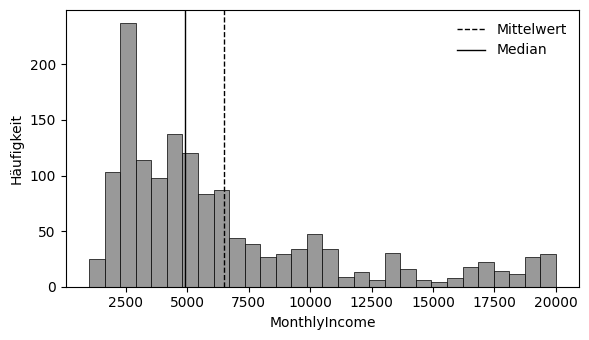

Mittelwert: 6502.93
Median:     4919.0
Schiefe:    1.37


In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(df_referenz['MonthlyIncome'], bins=30, color='0.6', edgecolor='black', linewidth=0.5)
ax.axvline(df_referenz['MonthlyIncome'].mean(), color='black', linestyle='--', linewidth=1, label='Mittelwert')
ax.axvline(df_referenz['MonthlyIncome'].median(), color='black', linestyle='-', linewidth=1, label='Median')
ax.set_xlabel('MonthlyIncome')
ax.set_ylabel('Häufigkeit')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / f'verteilung_monthlyincome{FILE_SUFFIX}.pdf')
plt.show()

# Kontrolle: Schiefe und Lagemaße
print('Mittelwert:', round(df_referenz['MonthlyIncome'].mean(), 2))
print('Median:    ', round(df_referenz['MonthlyIncome'].median(), 2))
print('Schiefe:   ', round(df_referenz['MonthlyIncome'].skew(), 3))